# 🏠 House Prices · PART 01 機器學習基礎 · Mini Project

這份 notebook 帶你把 **PART 01 的所有概念實打實踩一遍**。
目標**不是衝 Kaggle 排行榜**，而是親眼看到「模型一步步變強、為什麼變強」。

| 步驟 | 做什麼 | 對應 Part 1 概念 |
|------|--------|-----------------|
| ① EDA + 線性 baseline | 認識資料、建立基準線 | Baseline 心法、Linear Regression、Loss(RMSE) |
| ② Feature Engineering + RandomForest | 加工特徵、種樹林 | Bagging 降 variance、Feature importance |
| ③ XGBoost + 5-fold CV | 表格之王 + 交叉驗證 | Boosting、Cross-validation |
| ④ Train/Val curve | 診斷模型 | **Bias-Variance trade-off** |
| ⑤ 總結報告 | 每步進步多少、為什麼 | 串起所有概念 |

**怎麼用**：從上到下，一格一格按 `Shift + Enter` 執行，邊跑邊看輸出與註解。


## 第 0 步 · 載入工具與資料

先 import 需要的套件，並讀進 `train.csv`（1460 筆房屋、80 個特徵 + 目標 `SalePrice`）。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb

# 讓圖表能顯示中文（Windows 內建微軟正黑體）
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

DATA = r'C:\Users\uger\Desktop\ML-basic-notes\kaggle-house-prices\data'
train = pd.read_csv(DATA + r'\train.csv')
print('資料形狀 (筆數, 欄位數):', train.shape)
train.head()

資料形狀 (筆數, 欄位數): (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 為什麼要對目標取 log？

房價是「右偏」分佈（少數豪宅特別貴，把分佈拉長）。直接預測原始房價，
這些貴的房子會主導誤差。所以我們預測 **log(房價)**：
- 讓分佈接近常態，模型更好學
- 這也正是 Kaggle 這個競賽的官方評分方式（RMSE of log price）

> 🔗 對應概念：**Loss function**。我們選 RMSE 當作「怎麼定義好」，而且在 log 空間上算。


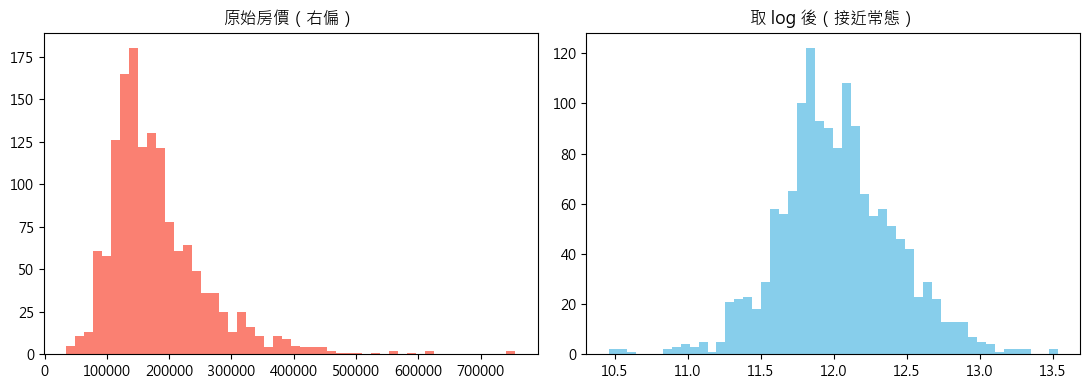

In [2]:
# 目標：取 log1p（log(1+x)，避免 log(0)）
y = np.log1p(train['SalePrice'])

# 畫出取 log 前後的分佈對比
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(train['SalePrice'], bins=50, color='salmon')
ax[0].set_title('原始房價（右偏）')
ax[1].hist(y, bins=50, color='skyblue')
ax[1].set_title('取 log 後（接近常態）')
plt.tight_layout(); plt.show()

# 統一的評分函數：RMSE（越小越好）
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## 第 1 步 · EDA + 線性 Baseline

**EDA（探索式資料分析）**＝先認識資料，再建模。我們看三件事：
1. 哪些欄位有**缺失值**（之後要處理）
2. 哪些特徵跟房價**最相關**
3. 建一個最簡單的 **Linear Regression** 當 **baseline（基準線）**

> 🔗 對應概念：**Baseline 心法**——「第一個模型永遠先跑線性，給你一條基準線。」


In [3]:
# (1) 缺失值前 10 名
missing = train.isnull().sum().sort_values(ascending=False)
print('缺失值最多的 10 個欄位：')
print(missing.head(10))

缺失值最多的 10 個欄位：
PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
dtype: int64


In [4]:
# (2) 與房價最相關的數值特徵
num_cols = train.select_dtypes(include=[np.number])
corr = num_cols.corr()['SalePrice'].sort_values(ascending=False)
print('與房價正相關最強的 8 個特徵：')
print(corr.head(9))   # 第一個是 SalePrice 自己

與房價正相關最強的 8 個特徵：
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
Name: SalePrice, dtype: float64


上面可以看到 `OverallQual`(整體品質)、`GrLivArea`(地上居住面積) 等跟房價高度相關，
符合常識：品質好、坪數大 → 房價高。

接著建 **baseline**：只用「數值欄位」、缺值用中位數補，跑 Linear Regression。
記住這個分數，後面所有模型都要跟它比。


In [5]:
# 只取數值特徵（去掉 Id 和目標），缺值用中位數補
Xb = num_cols.drop(columns=['Id', 'SalePrice']).fillna(num_cols.median(numeric_only=True))

# 切出 80% 訓練 / 20% 驗證
Xtr, Xva, ytr, yva = train_test_split(Xb, y, test_size=0.2, random_state=42)

lr = LinearRegression().fit(Xtr, ytr)
base_rmse = rmse(yva, lr.predict(Xva))
print(f'★ Baseline（Linear Regression）驗證 RMSE = {base_rmse:.4f}')
print('  （這就是基準線，越小越好）')

★ Baseline（Linear Regression）驗證 RMSE = 0.1519
  （這就是基準線，越小越好）


## 第 2 步 · Feature Engineering + RandomForest

兩個改進一起上：
1. **Feature Engineering（特徵工程）**：手動加工出更有意義的特徵
   （總面積、總衛浴、屋齡、門廊總面積…）
2. 把**所有特徵**（含文字類的分類特徵）用 one-hot 編碼後，跑 **RandomForest**

> 🔗 對應概念：**Bagging 降 variance**（很多棵樹投票）、**Feature importance**。


In [6]:
def make_features(df):
    df = df.copy()
    # 總面積 = 地下室 + 1樓 + 2樓
    df['TotalSF'] = df[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']].fillna(0).sum(axis=1)
    # 總衛浴數（半套算 0.5）
    df['TotalBath'] = (df['FullBath'].fillna(0) + 0.5 * df['HalfBath'].fillna(0)
                       + df['BsmtFullBath'].fillna(0) + 0.5 * df['BsmtHalfBath'].fillna(0))
    # 屋齡、改建後屋齡
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    # 門廊/露台總面積
    df['TotalPorch'] = df[['OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
                           'ScreenPorch', 'WoodDeckSF']].fillna(0).sum(axis=1)
    return df

feat = make_features(train).drop(columns=['Id', 'SalePrice'])

# one-hot 編碼：把文字分類欄位（如社區、房型）轉成 0/1 欄位
X = pd.get_dummies(feat, dummy_na=False)
X = X.fillna(X.median(numeric_only=True))
print('特徵工程 + one-hot 後的欄位數：', X.shape[1], '（原本 80）')

Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, random_state=42)

特徵工程 + one-hot 後的欄位數： 292 （原本 80）


In [7]:
rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)
rf.fit(Xtr, ytr)
rf_rmse = rmse(yva, rf.predict(Xva))
print(f'★ RandomForest 驗證 RMSE = {rf_rmse:.4f}')
print(f'  Baseline 是 {base_rmse:.4f} → 進步了 {base_rmse - rf_rmse:.4f}')

★ RandomForest 驗證 RMSE = 0.1451
  Baseline 是 0.1519 → 進步了 0.0067


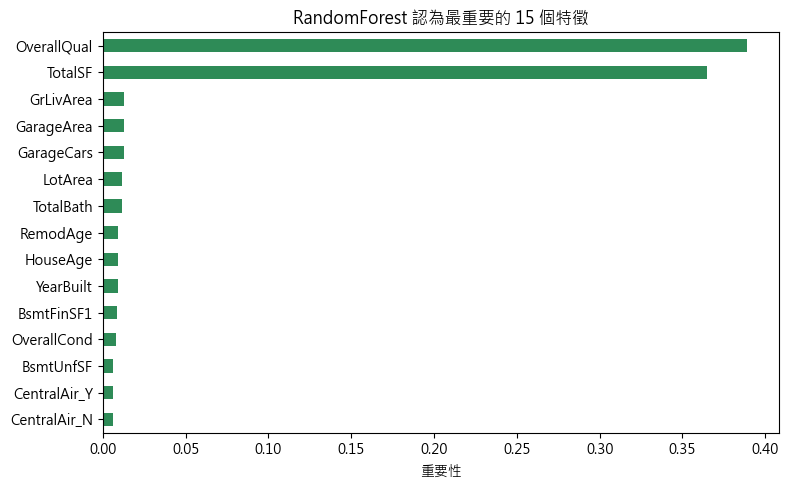

In [8]:
# RandomForest 的 feature importance：哪些特徵最重要？
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.head(15).iloc[::-1].plot(kind='barh', color='seagreen')
plt.title('RandomForest 認為最重要的 15 個特徵')
plt.xlabel('重要性'); plt.tight_layout(); plt.show()

## 第 3 步 · XGBoost + 5-fold 交叉驗證

上**表格之王 XGBoost**，並用 **5-fold Cross-Validation** 評估。

**為什麼用 CV？** 只用固定一份驗證集，分數可能只是運氣好。
5-fold＝把資料切 5 份輪流當驗證，取平均 → 分數更可信，**不會自己騙自己**。

> 🔗 對應概念：**Boosting**（一棵補一棵的錯）、**Cross-validation**。


In [9]:
xgb_model = xgb.XGBRegressor(
    n_estimators=2000,      # 種 2000 棵樹
    learning_rate=0.03,    # 每棵樹小步走（防 overfit）
    max_depth=4,           # 每棵樹不要太深
    min_child_weight=5,         # 葉子要更「紮實」才分裂
    subsample=0.5,
    colsample_bytree=0.5,
    reg_lambda=5.0,             # L2 懲罰（weight decay）
    reg_alpha=1.5,              # L1 懲罰
    #early_stopping_rounds=100,   # val 連續 100 棵沒進步就停
    random_state=42,
)

# 5-fold CV：cross_val_score 回傳負的 RMSE，取負號變正
cv_scores = -cross_val_score(xgb_model, X, y, cv=5,
                             scoring='neg_root_mean_squared_error')
print('5 折各自的 RMSE：', np.round(cv_scores, 4))
print(f'★ XGBoost 5-fold 平均 RMSE = {cv_scores.mean():.4f} (±{cv_scores.std():.4f})')

# 也在同一份 holdout 上算一次，方便跟前面公平比較
xgb_model.fit(Xtr, ytr)
xgb_rmse = rmse(yva, xgb_model.predict(Xva))
print(f'  XGBoost holdout RMSE = {xgb_rmse:.4f}')

5 折各自的 RMSE： [0.1143 0.1328 0.1323 0.1109 0.1365]
★ XGBoost 5-fold 平均 RMSE = 0.1253 (±0.0106)
  XGBoost holdout RMSE = 0.1331


## 第 4 步 · 畫 Train/Val Curve，看 Bias-Variance

這是**整個專案最重要的學習點**！我們畫一張「學習曲線」：
- X 軸：用多少訓練資料
- Y 軸：RMSE（train 一條線、val 一條線）

**怎麼判讀（複習 Part 1）：**
- 兩條線**差很開**（train 很低、val 很高）→ **OVERFIT（high variance，死背）**
- 兩條線**都很高**（一起爛）→ **UNDERFIT（high bias，太笨）**
- 兩條線**靠近且都低** → 剛剛好

> 🔗 對應概念：**Bias-Variance trade-off**——抽象的概念，這裡變成你親眼看到的兩條線。


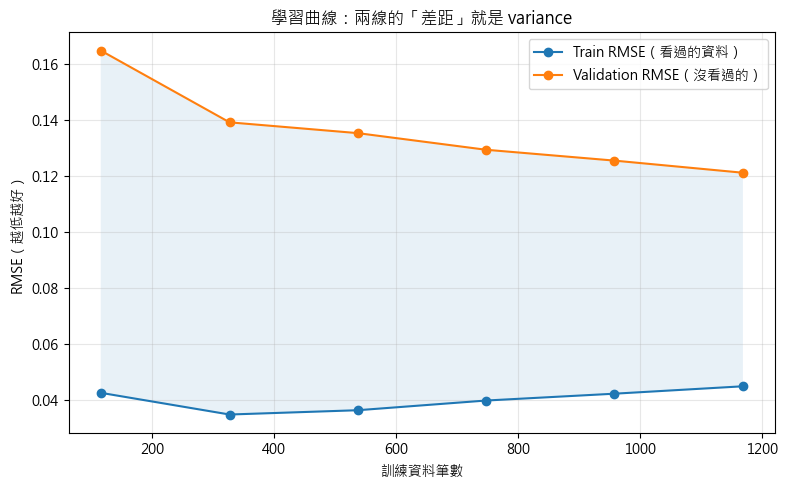

最終 train RMSE = 0.0449, val RMSE = 0.1211
兩者差距（variance 指標）= 0.0763


In [10]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb.XGBRegressor(
    n_estimators=2500,      # 種 2000 棵樹
    learning_rate=0.03,    # 每棵樹小步走（防 overfit）
    max_depth=3,           # 每棵樹不要太深
    min_child_weight=4,         # 葉子要更「紮實」才分裂
    subsample=0.6,
    colsample_bytree=0.6,
    reg_lambda=1.0,             # L2 懲罰（weight decay）
    reg_alpha=0.5,              # L1 懲罰
    #early_stopping_rounds=100,   # val 連續 100 棵沒進步就停
    random_state=42,
    ),
    X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, 'o-', label='Train RMSE（看過的資料）')
plt.plot(train_sizes, val_rmse, 'o-', label='Validation RMSE（沒看過的）')
plt.fill_between(train_sizes, train_rmse, val_rmse, alpha=0.1)
plt.xlabel('訓練資料筆數'); plt.ylabel('RMSE（越低越好）')
plt.title('學習曲線：兩線的「差距」就是 variance')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'最終 train RMSE = {train_rmse[-1]:.4f}, val RMSE = {val_rmse[-1]:.4f}')
print(f'兩者差距（variance 指標）= {val_rmse[-1] - train_rmse[-1]:.4f}')

## 第 5 步 · 總結報告：每步進步多少、為什麼

把四個模型的分數放在一起看。**RMSE 越低越好。**


In [11]:
report = pd.DataFrame({
    '模型': ['① Linear baseline', '② + 特徵工程 + RandomForest', '③ XGBoost (holdout)'],
    'RMSE': [base_rmse, rf_rmse, xgb_rmse],
})
report['比 baseline 進步'] = base_rmse - report['RMSE']
print(report.to_string(index=False))
print(f'\nXGBoost 5-fold 平均 RMSE = {cv_scores.mean():.4f}（最可信的分數）')

                     模型     RMSE  比 baseline 進步
      ① Linear baseline 0.151864       0.000000
② + 特徵工程 + RandomForest 0.145120       0.006744
    ③ XGBoost (holdout) 0.133064       0.018800

XGBoost 5-fold 平均 RMSE = 0.1253（最可信的分數）


### 📝 你的學習筆記（請自己填寫思考）

把你觀察到的寫下來——這才是真正的學習成果：

1. **Baseline RMSE 是多少？** 0.1519
2. **加了特徵工程 + RandomForest 後進步多少？為什麼？** 進步了 0.0067，因為random forest利用隨機取樹的方式，增加了多樣性，可以涵蓋更多種情況，才不會容易死背 overfit
   （提示：RandomForest 用很多棵樹投票，降低了 variance；特徵工程給了模型更有用的資訊）
3. **XGBoost 又進步多少？為什麼它在表格資料上特別強？** 0.021325，因為這個方法就像gradient decsent，會不斷地去往loss較小的方向作修正，當達到一定的步數後，會有最好的準確度
   （提示：boosting 一棵接一棵補錯，且能抓到非線性關係）
4. **看學習曲線：你的模型是偏 overfit 還是 underfit？** overfit，因為val遠大於train
   （train 和 val 差很開 = overfit；要改善就：更多資料 / regularization）
5. **下一步可以怎麼再進步？**（提示：調參、更多特徵工程、處理 outlier）加更多特徵工程

---
🎉 **恭喜！你已經把 PART 01 的所有核心概念實際跑過一遍了。**


## 第 6 步 · 處理 Outlier（離群值）

調參把 val 從 0.1221 擠到 0.1211 後就接近天花板了。想再進步要換戰場——**處理離群值**。

### 為什麼 outlier 殺傷力大？（複習 Loss）

MSE 裡有個**平方項**：$L = \frac{1}{n}\sum (y_i - \hat{y}_i)^2$

預測差 5 倍 → 平方後變 **25 倍懲罰**。模型為了討好少數怪屋，會扭曲自己去遷就，反而把正常房子預測得更差。

House Prices 有幾棟「**坪數超大卻賣超便宜**」的房子（建商特殊交易、非市場價），就是頭號戰犯。

> 🔗 對應概念：**Loss function（MSE 的平方項對離群值極度敏感）**。

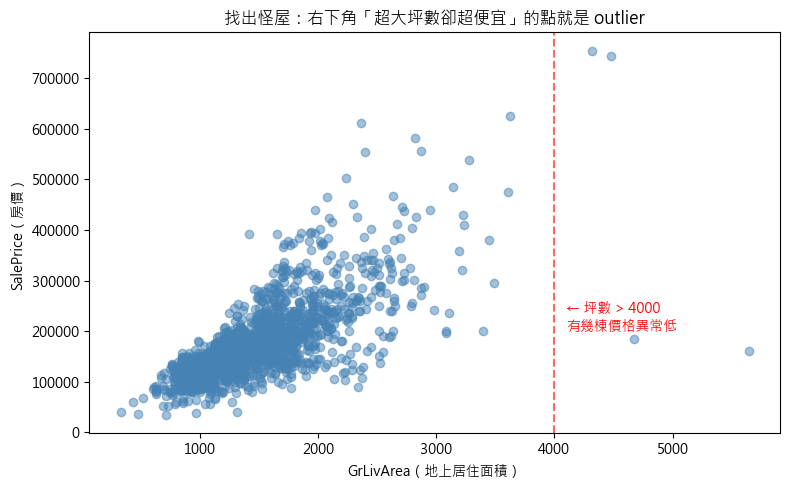

坪數 > 4000 的房子：
        Id  GrLivArea  SalePrice  OverallQual
1298  1299       5642     160000           10
523    524       4676     184750           10
1182  1183       4476     745000           10
691    692       4316     755000           10


In [12]:
# 第 1 步：先「看見」怪屋——畫 居住面積 vs 房價 散點圖
plt.figure(figsize=(8, 5))
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, color='steelblue')
plt.xlabel('GrLivArea（地上居住面積）')
plt.ylabel('SalePrice（房價）')
plt.title('找出怪屋：右下角「超大坪數卻超便宜」的點就是 outlier')
plt.axvline(4000, color='red', linestyle='--', alpha=0.6)
plt.text(4100, 200000, '← 坪數 > 4000\n有幾棟價格異常低', color='red')
plt.tight_layout(); plt.show()

# 把可疑的點列出來
suspects = train[train['GrLivArea'] > 4000][['Id', 'GrLivArea', 'SalePrice', 'OverallQual']]
print('坪數 > 4000 的房子：')
print(suspects.sort_values('SalePrice'))

上圖右下角那幾個脫隊的點：**坪數爆大（>4000）但價格低得離譜**，就是要除掉的戰犯。

下面用「**坪數 > 4000 且 房價 < 300000**」的雙條件精準鎖定——
坪數大不是罪（正常豪宅也會 >4000），我們只殺「又大又異常便宜」的，**不誤傷無辜**。

In [13]:
# 第 2 步：刪掉怪屋，用乾淨資料重建 X 和 y
before = len(train)
train_clean = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))].copy()
print(f'刪掉了 {before - len(train_clean)} 棟怪屋（{before} → {len(train_clean)} 筆）')

y_clean = np.log1p(train_clean['SalePrice'])
feat_clean = make_features(train_clean).drop(columns=['Id', 'SalePrice'])
X_clean = pd.get_dummies(feat_clean, dummy_na=False)
X_clean = X_clean.fillna(X_clean.median(numeric_only=True))
print('重建後欄位數：', X_clean.shape[1])

刪掉了 2 棟怪屋（1460 → 1458 筆）
重建後欄位數： 291


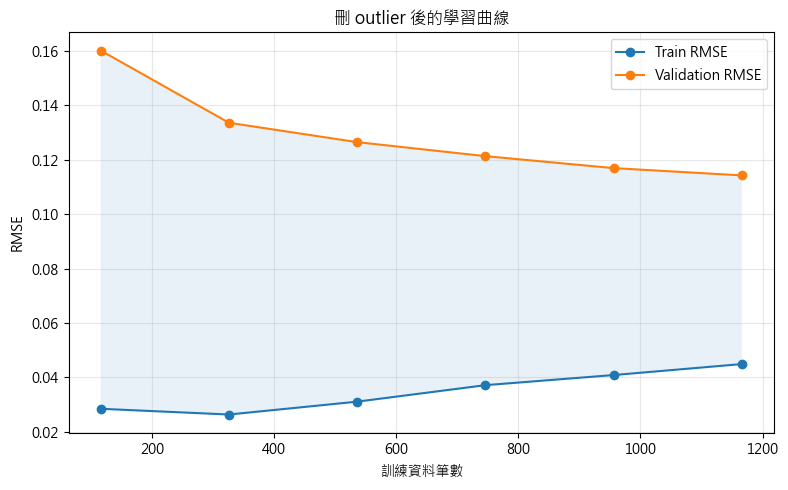

刪 outlier 後：train RMSE = 0.0449, val RMSE = 0.1142
（對照：刪之前 val = 0.1211）


In [14]:
# 第 3 步：用調好的溫和版參數，在乾淨資料上重跑學習曲線，看 val 有沒有降
train_sizes, train_scores, val_scores = learning_curve(
    xgb.XGBRegressor(
        n_estimators=2500, learning_rate=0.02, max_depth=3,
        min_child_weight=3, subsample=0.7, colsample_bytree=0.7,
        reg_lambda=2.0, reg_alpha=0.3, random_state=42,
    ),
    X_clean, y_clean, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, 'o-', label='Train RMSE')
plt.plot(train_sizes, val_rmse, 'o-', label='Validation RMSE')
plt.fill_between(train_sizes, train_rmse, val_rmse, alpha=0.1)
plt.xlabel('訓練資料筆數'); plt.ylabel('RMSE')
plt.title('刪 outlier 後的學習曲線')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'刪 outlier 後：train RMSE = {train_rmse[-1]:.4f}, val RMSE = {val_rmse[-1]:.4f}')
print(f'（對照：刪之前 val = 0.1211）')